In [1]:
import pandas 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
red_wine_raw = pandas.read_csv("D:\\Data Ethics\\Ethics Group 5 Project 5 Wine\\winequality-red.csv",header=0, sep=";")

In [4]:
red_wine_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
red_wine_raw['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

### Pre Processing 

In [7]:
red_wine = red_wine_raw.copy()

In [8]:
red_wine['bad_wine'] = red_wine_raw['quality'] < 5
red_wine['normal_wine'] = (red_wine_raw['quality'] >= 5) & (red_wine_raw['quality'] <= 6)
red_wine['good_wine'] = red_wine_raw['quality'] >= 7


In [9]:
red_wine['bad_wine'] = red_wine['bad_wine'].astype(int)
red_wine['normal_wine'] = red_wine['normal_wine'].astype(int)
red_wine['good_wine'] = red_wine['good_wine'].astype(int)

In [10]:
red_wine = red_wine.drop(columns=['quality'])

In [11]:
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,bad_wine,normal_wine,good_wine
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0,1,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0,1,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0,1,0


In [12]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  bad_wine              1599 non-null   int32  
 12  normal_wine           1599 non-null   int32  
 13  good_wine             1599 non-null   int32  
dtypes: float64(11), int32(3)
memory usage: 156.3 KB


In [13]:
red_wine[['bad_wine', 'normal_wine', 'good_wine']].value_counts()

bad_wine  normal_wine  good_wine
0         1            0            1319
          0            1             217
1         0            0              63
Name: count, dtype: int64

### Excluding duplicate entries and data points with missing values from all wine category dataframes

In [14]:
red_wine.duplicated().sum()

240

In [15]:
red_wine.drop_duplicates(inplace=True)

In [16]:
red_wine.dropna(inplace=True)

In [17]:
red_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  bad_wine              1359 non-null   int32  
 12  normal_wine           1359 non-null   int32  
 13  good_wine             1359 non-null   int32  
dtypes: float64(11), int32(3)
memory usage: 143.3 KB


In [18]:
red_wine[['bad_wine', 'normal_wine', 'good_wine']].value_counts()

bad_wine  normal_wine  good_wine
0         1            0            1112
          0            1             184
1         0            0              63
Name: count, dtype: int64

- After droping duplicates and missing values new values in each dataframe are 
    - bad wine = 63 having no duplicates or missing values
    - normal wine = 1112 having 207 rows dropped
    - good wine = 184 having 33 rows dropped

## Analysis

### Correlation Matrix

- So they used the entire dataset for this correlation matrix and the paper does not specify that they did this before or after preprocessing. So to see the differences I did a a correlation with the raw data and then make another after the preprocessing, the one in the paper is one that is done before pre processing and matches exactly.

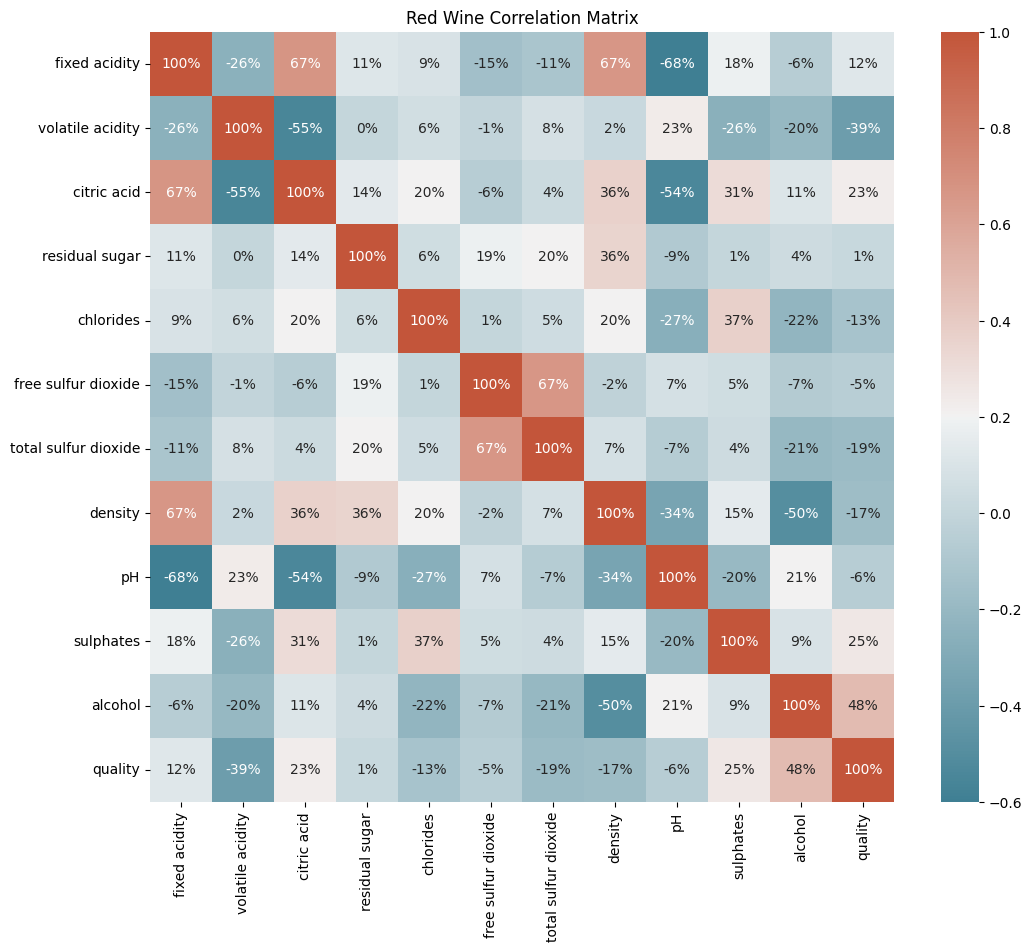

In [27]:
# Before preprocessing just doing a initial data exploration 
correlation_matrix = red_wine_raw.corr()
percent_labels = correlation_matrix.multiply(100).round().astype(int).astype(str) + '%' # To match the paper's correlation matrix with percentage labels
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=percent_labels, fmt='',
            cmap= sns.diverging_palette(220, 20, as_cmap=True), vmin=-0.6, vmax=1) # Adjusted vmin and vmax for better color contrast and readability to reproduce the paper
plt.title('Red Wine Correlation Matrix')
plt.show()

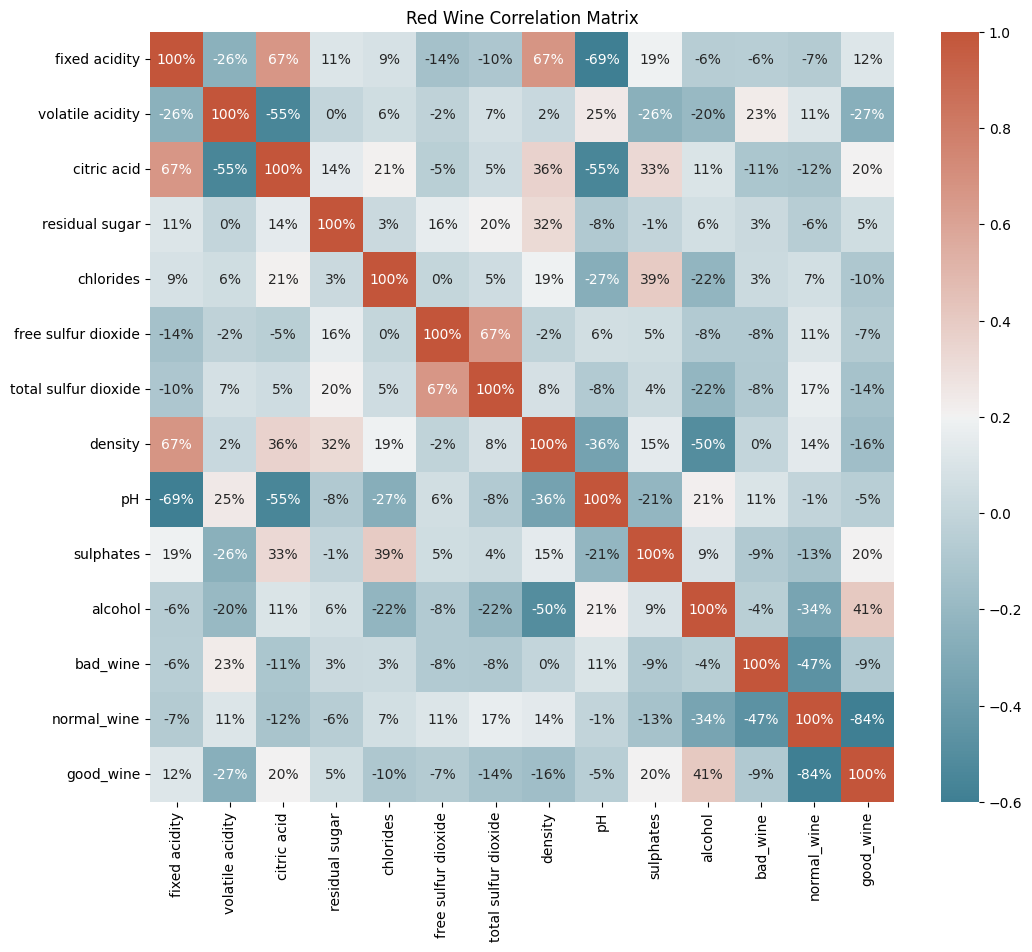

In [28]:
## After preprocessing 
correlation_matrix = red_wine.corr()
percent_labels = correlation_matrix.multiply(100).round().astype(int).astype(str) + '%'
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=percent_labels, fmt='',
            cmap= sns.diverging_palette(220, 20, as_cmap=True), vmin=-0.6, vmax=1)
plt.title('Red Wine Correlation Matrix')
plt.show()
